### Importación de datos



In [11]:
import pandas as pd

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv"

tienda = pd.read_csv(url)
tienda2 = pd.read_csv(url2)
tienda3 = pd.read_csv(url3)
tienda4 = pd.read_csv(url4)

tienda.head()

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
0,Asistente virtual,Electrónicos,164300.0,6900.0,16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175
1,Mesa de comedor,Muebles,192300.0,8400.0,18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25184,-75.56359
2,Juego de mesa,Juguetes,209600.0,15900.0,15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.39972,-75.51444
3,Microondas,Electrodomésticos,757500.0,41000.0,03/05/2022,Juan Fernandez,Cali,4,Nequi,1,3.43722,-76.52250
4,Silla de oficina,Muebles,335200.0,20200.0,07/11/2020,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359


In [12]:
tienda4.isnull().sum()

,0
Producto,0
Categoría del Producto,0
Precio,0
Costo de envío,0
Fecha de Compra,0
Vendedor,0
Lugar de Compra,0
Calificación,0
Método de pago,0
Cantidad de cuotas,0


#1. Análisis de facturación



In [13]:
tienda.head(10)

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
0,Asistente virtual,Electrónicos,164300.0,6900.0,16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175
1,Mesa de comedor,Muebles,192300.0,8400.0,18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25184,-75.56359
2,Juego de mesa,Juguetes,209600.0,15900.0,15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.39972,-75.51444
3,Microondas,Electrodomésticos,757500.0,41000.0,03/05/2022,Juan Fernandez,Cali,4,Nequi,1,3.43722,-76.52250
4,Silla de oficina,Muebles,335200.0,20200.0,07/11/2020,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359
5,Bloques de construcción,Juguetes,24200.0,0.0,03/12/2020,Beatriz Morales,Cali,5,Cupón,1,3.43722,-76.52250
6,Muñeca bebé,Juguetes,44200.0,0.0,07/08/2021,Juan Fernandez,Bogotá,3,Nequi,1,4.60971,-74.08175
7,Lavavajillas,Electrodomésticos,1189700.0,63700.0,18/06/2021,Felipe Santos,Santa Marta,5,Tarjeta de crédito,10,11.24079,-74.19904
8,Lavadora de ropa,Electrodomésticos,1518200.0,79000.0,08/01/2022,Izabela de León,Bogotá,1,Tarjeta de crédito,5,4.60971,-74.08175
9,Carrito de control remoto,Juguetes,75200.0,5100.0,24/02/2020,Beatriz Morales,Bogotá,5,Nequi,1,4.60971,-74.08175


In [14]:
datos= [['Tienda 1', tienda["Precio"].sum()], ['Tienda 2', tienda2["Precio"].sum()], ['Tienda 3', tienda3["Precio"].sum()], ['Tienda 4', tienda4["Precio"].sum()]]

facturacion = pd.DataFrame(datos, columns=['Tienda', 'Facturacion'])
print(facturacion)

     Tienda   Facturacion
0  Tienda 1  1.150880e+09
1  Tienda 2  1.116344e+09
2  Tienda 3  1.098020e+09
3  Tienda 4  1.038376e+09


In [15]:
facturacion = facturacion.groupby('Tienda')[['Facturacion']].mean().sort_values('Facturacion')

<Axes: xlabel='Tienda', ylabel='Facturacion total'>

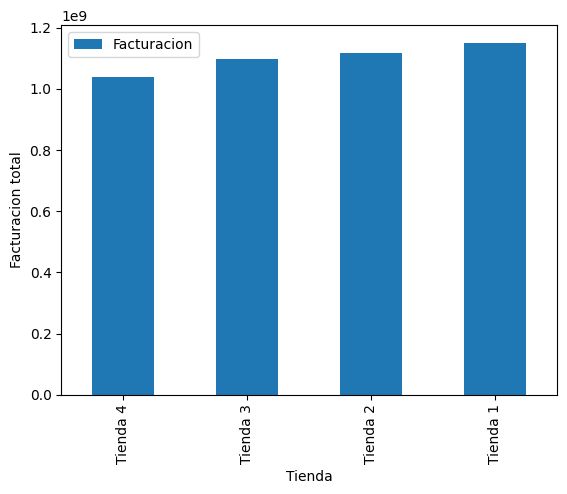

In [16]:
facturacion.plot(kind='bar', xlabel='Tienda', ylabel='Facturacion total')

# 2. Ventas por categoría

In [33]:
Ventas_cat_t1 = tienda.groupby('Categoría del Producto')['Precio'].count().sort_values(ascending=False)
Ventas_cat_t2 = tienda2.groupby('Categoría del Producto')['Precio'].count().sort_values(ascending=False)
Ventas_cat_t3 = tienda3.groupby('Categoría del Producto')['Precio'].count().sort_values(ascending=False)
Ventas_cat_t4 = tienda4.groupby('Categoría del Producto')['Precio'].count().sort_values(ascending=False)


In [52]:
Ventas_cat_t1 = Ventas_cat_t1.rename('Tienda 1')
Ventas_cat_t2 = Ventas_cat_t2.rename('Tienda 2')
Ventas_cat_t3 = Ventas_cat_t3.rename('Tienda 3')
Ventas_cat_t4 = Ventas_cat_t4.rename('Tienda 4')


In [93]:
Ventas_cat_total = pd.merge(Ventas_cat_t1, Ventas_cat_t2, on='Categoría del Producto', how='outer')
Ventas_cat_total = pd.merge(Ventas_cat_total, Ventas_cat_t3, on='Categoría del Producto', how='outer')
Ventas_cat_total = pd.merge(Ventas_cat_total, Ventas_cat_t4, on='Categoría del Producto', how='outer')
Ventas_cat_total.drop('Tienda_asignada', inplace=True)


,Tienda 1,Tienda 2,Tienda 3,Tienda 4
Categoría del Producto,,,,
Artículos para el hogar,171,181.0,177.0,201.0
Deportes y diversión,284,275.0,277.0,277.0
Electrodomésticos,312,305.0,278.0,254.0
Electrónicos,448,422.0,451.0,451.0
Instrumentos musicales,182,224.0,177.0,170.0
Juguetes,324,313.0,315.0,338.0
Libros,173,197.0,185.0,187.0
Muebles,465,442.0,499.0,480.0


<Axes: xlabel='Tienda', ylabel='Ventas'>

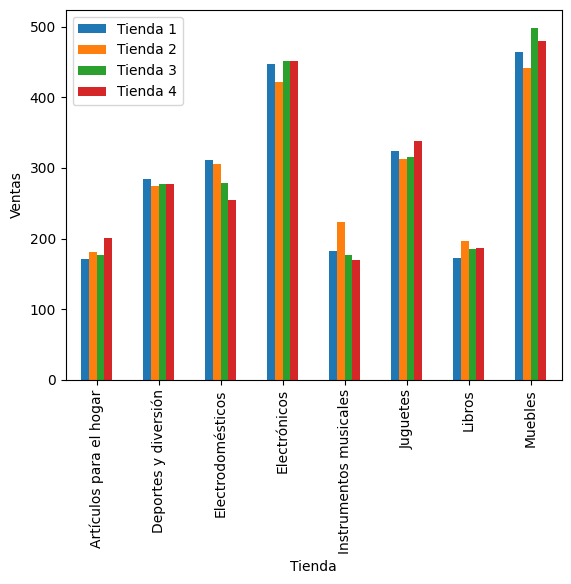

In [102]:
Ventas_cat_total = Ventas_cat_total.groupby('Categoría del Producto').sum()
Ventas_cat_total.plot(kind='bar', xlabel='Tienda', ylabel='Ventas')

# 3. Calificación promedio de la tienda


<Axes: xlabel='Tienda', ylabel='Promedio'>

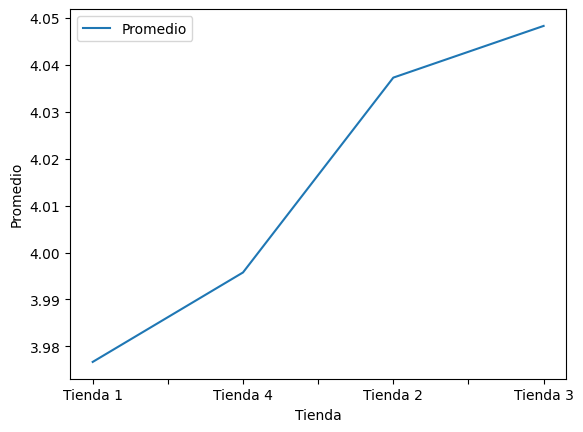

In [107]:
promedios = [['Tienda 1', tienda['Calificación'].mean()], ['Tienda 2',tienda2['Calificación'].mean()], ['Tienda 3',tienda3['Calificación'].mean()], ['Tienda 4',tienda4['Calificación'].mean()]]
df_promedios = pd.DataFrame(promedios,columns=['Tienda', 'Promedio'])
df_promedios = df_promedios.groupby('Tienda')[['Promedio']].mean().sort_values('Promedio')
df_promedios.plot(kind='line', xlabel='Tienda', ylabel='Promedio')

# 4. Productos más y menos vendidos

In [108]:
producto_t1 = tienda.groupby('Producto')['Precio'].count().sort_values(ascending=False)
producto_t2 = tienda2.groupby('Producto')['Precio'].count().sort_values(ascending=False)
producto_t3 = tienda3.groupby('Producto')['Precio'].count().sort_values(ascending=False)
producto_t4 = tienda4.groupby('Producto')['Precio'].count().sort_values(ascending=False)

In [109]:
producto_t1 = producto_t1.rename('Tienda 1')
producto_t2 = producto_t2.rename('Tienda 2')
producto_t3 = producto_t3.rename('Tienda 3')
producto_t4 = producto_t4.rename('Tienda 4')

In [111]:
ventas_prod_total = pd.merge(producto_t1, producto_t2, on='Producto', how='outer')
ventas_prod_total = pd.merge(ventas_prod_total, producto_t3, on='Producto', how='outer')
ventas_prod_total = pd.merge(ventas_prod_total, producto_t4, on='Producto', how='outer')


In [114]:
ventas_prod_total = ventas_prod_total.groupby('Producto').sum()
#ventas_prod_total.plot(kind='line', xlabel='Tienda', ylabel='Ventas')
ventas_prod_total

,Tienda 1,Tienda 2,Tienda 3,Tienda 4
Producto,,,,
Ajedrez de madera,49,45,47,39
Armario,60,54,49,34
Asistente virtual,40,38,39,50
Auriculares,50,37,43,44
Auriculares con micrófono,33,44,39,42
Balón de baloncesto,55,42,50,50
Balón de voleibol,42,46,48,48
Batería,53,61,41,48
Bicicleta,54,45,52,45


# 5. Envío promedio por tienda

<Axes: ylabel='Tienda'>

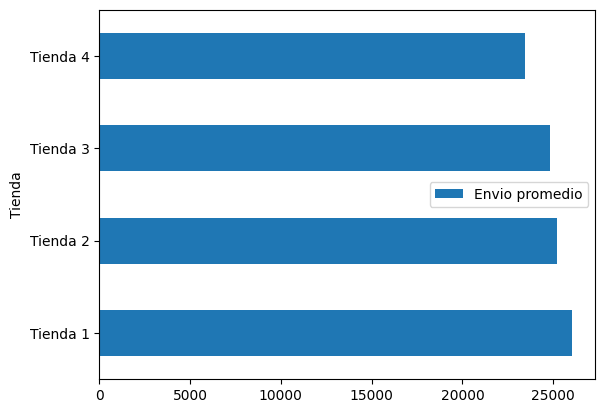

In [26]:
envio_promedio = [['Tienda 1', tienda['Costo de envío'].mean()], ['Tienda 2',tienda2['Costo de envío'].mean()], ['Tienda 3',tienda3['Costo de envío'].mean()], ['Tienda 4',tienda4['Costo de envío'].mean()]]
df_envio_promedio = pd.DataFrame(envio_promedio,columns=['Tienda', 'Envio promedio'])
df_envio_promedio.groupby('Tienda').sum().plot(kind='barh')

**Informe Final**

El ranking de tiendas con mayor ventas es de tienda 1 como la principal y tienda 4 como la que menos facturación tiene.
Si bien es cierto, la tienda 1 cuenta con mayor facturación general, cada tienda tiene su parte atractiva al momento de separarlo por categoría y producto. Tomando como ejemplo la categoría "Artículos para el hogar", la tienda 4 cuenta con un mayor volumen de ventas, vendiendo un 17% con respecto a la tienda 1.

Asimismo, si bien se encuentran casi parejos, la tienda 1 a pesar de contar con mayor facturación global, esta cuenta con el peor promedio de calificación de los clientes.

Por otro lado, podemos observar que el costo de envió promedio por cada tienda está inversamente proporcional a la facturación, lo que muestra el reflejo de que no se encuentran directamente asociados.

Como conclusión y revisando la información brindada. No se sugiere el cierre de ninguna tienda, por el contrario. Se propone realizar una especialización por tienda, en donde cada tienda cuente con las categorías/productos en donde se especializa mejor, así enfocando los esfuerzos de cada una. De esta manera, se reflejaría una eficiencia de aproximadamente 15% (diferencias de categorías/tiendas), logrando una facturación estable entre todas las tiendas.
Por otro lado, se sugiere revisar un mapa de calor de envíos para poder identificar zonas específicas y zonificar los envíos en base a la tienda mas cercana.